# Notebook 1: Data Cleaning + Merging for Global Data Science Project
This notebook handles the cleaning and merging of five global datasets following best practices and the PACE workflow.

In [10]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set(style="whitegrid")

In [11]:
# ==============================
# LOAD ALL WORLD BANK DATASETS
# ==============================

# World Bank files ke liye 'skiprows=4' lagana zaroori hai
mortality_df = pd.read_csv('data/raw/worldbank_mortality.csv', skiprows=4, encoding='latin1')
gdp_df = pd.read_csv('data/raw/worldbank_gdp.csv', skiprows=4, encoding='latin1')
health_df = pd.read_csv('data/raw/worldbank_health_exp.csv', skiprows=4, encoding='latin1')

# Preview
print("Mortality Data Loaded Successfully!")
display(mortality_df.head())

print("GDP Data Loaded Successfully!")
display(gdp_df.head())

print("Health Data Loaded Successfully!")
display(health_df.head())

Mortality Data Loaded Successfully!


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,7.525000,7.347000,7.066000,6.863000,6.689000,6.572000,6.384000,6.348000,6.263000,6.186000,6.127000,6.079000,4.738000,4.923000,5.107000,4.906000,5.140000,5.463000,4.832000,5.372000,4.807000,5.234000,5.108000,5.448000,5.135000,5.411000,6.291000,6.255000,5.646000,6.155000,6.677000,6.506000,6.144000,5.456000,5.554000,6.315000,5.649000,5.759000,5.709000,6.257000,5.850000,4.757000,5.344000,5.380000,5.277000,4.937000,5.422000,5.322000,5.490000,6.191000,6.078000,6.258000,5.850000,5.422000,6.114000,6.367000,7.257000,6.594000,6.703000,6.145000,6.842000,8.951000,8.191000,7.582000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,20.965499,20.745542,20.443071,20.234375,19.903705,19.767112,19.882408,19.289492,19.064012,18.892881,18.681107,18.427896,18.781047,18.178905,18.247036,18.080120,17.541365,17.351246,17.192454,16.913236,16.702722,16.525449,16.325895,17.568734,17.455074,17.099104,16.596696,15.810748,16.260085,15.397403,15.389203,15.678462,15.762598,15.247952,17.245282,14.675475,14.653259,14.424374,14.677737,14.036359,13.549903,13.307649,13.039920,12.721459,12.383424,12.021091,11.537557,11.086597,10.662375,10.198401,9.807786,9.780321,9.065459,8.729366,8.601623,8.414717,8.242132,8.078590,7.673569,7.462279,7.540022,7.913646,7.245163,6.978621,NaN,NaN,NaN
2,Afghanistan,AFG,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,31.672000,31.129000,30.630000,30.168000,29.672000,29.193000,28.733000,28.265000,27.801000,27.334000,26.838000,26.383000,25.882000,25.364000,24.889000,24.403000,23.934000,23.404000,24.171000,25.538000,25.706000,26.413000,28.026000,27.013000,32.008000,31.699000,25.044000,24.617000,20.606000,19.582000,19.479000,18.783000,17.170000,14.613000,14.929000,14.403000,13.928000,13.651000,13.886000,12.697000,12.608000,11.954000,11.187000,10.714000,10.375000,9.913000,9.659000,9.487000,8.884000,8.645000,8.402000,8.032000,7.822000,7.597000,7.511000,7.528000,7.320000,7.315000,7.271000,7.064000,7.565000,8.002000,5.993000,5.797000,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,26.442827,26.204642,25.726181,25.533288,25.332275,25.094089,24.890916,25.063310,24.406693,24.159559,23.577564,23.206235,22.669625,22.251298,21.793593,21.377683,20.750054,20.263916,19.872628,19.511851,19.206999,18.856534,18.567372,18.390099,18.193180,18.014355,17.867278,17.722271,17.507300,17.361032,17.351095,17.208861,17.036495,16.869435,16.788047,16.598689,16.483600,16.327854,16.107015,15.821821,15.477978,15.189717,14.866663,14.520919,14.150840,13.840218,13.546824,13.204189,12.910720,13.405044,12.463234,12.231350,12.016282,11.829963,11.733277,11.467182,11.207935,11.026342,10.738329,10.695445,10.449272,10.398019,10.337587,9.640375,NaN,NaN,NaN
4,Angola,AGO,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,27.055000,28.075000,27.871000,27.648000,27.370000,27.087000,26.761000,26.362000,25.951000,25.518000,24.956000,24.318000,23.680000,23.163000,22.730000,22.973000,22.899000,22.492000,22.167000,21.878000,21.611000,21.387000,21.178000,21.881000,21.716000,21.572000,21.427000,22.993000,22.420000,22.217000,22.055000,20.535000,21.670000,21.448000,20.334000,18.700000,18.445000,18.184000,18.925000,18.518000,18.080000,17.606000,17.071000,15.559000,14.958000,14.310000,13.757000,12.980000,12.302000,11.702000,11.078000,10.546000,10.043000,9.578000,9.179000,8.809000,8.476000,8.192000,7.928000,7.701000,7.628000,7.619000,7.097000,6.925000,NaN,NaN,NaN


GDP Data Loaded Successfully!


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6767.559229,8244.045660,10056.261393,11507.217151,12187.536361,13233.990517,13892.605143,14700.959808,16055.287787,16548.717387,16620.954556,17750.009564,18828.087059,19216.197235,20681.023027,20740.132583,21307.248251,21949.485996,23700.631990,24171.837133,24845.658484,26736.308944,28171.909401,25134.771230,24093.140151,25712.384302,25119.665545,25813.571441,26129.839062,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,240.911794,243.773593,257.143823,281.578894,276.732924,294.814162,311.465053,389.729024,463.468775,479.078798,468.774522,518.358685,571.617317,634.448116,773.301205,777.627960,725.547511,732.345461,650.346841,554.221296,578.317452,664.791813,704.142066,728.243319,822.402999,864.174086,732.910915,709.323534,700.772126,766.522931,746.787335,767.399412,697.079415,670.424213,706.727261,625.827815,630.512328,815.432296,989.015464,1126.297323,1235.266608,1381.552597,1447.545754,1408.753467,1628.905248,1761.989261,1732.038021,1706.022744,1690.166792,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.930991,138.706822,178.954088,198.871116,221.763654,254.184249,274.218554,376.223152,381.733238,452.053705,560.621505,606.694676,651.417134,637.087099,625.054942,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,162.107340,144.940804,146.186183,161.917968,218.672141,195.859987,230.068904,280.643967,368.294725,413.366170,480.447260,490.839577,523.781318,624.870707,763.011988,1328.793688,1164.188488,873.979407,738.545691,754.905547,582.885076,583.317520,563.117147,512.477735,593.024667,607.840414,567.153365,574.472939,580.008123,866.731606,1069.590240,1091.831529,1141.486651,523.797280,518.969226,532.972787,619.337335,697.481256,838.213392,999.770023,1234.641856,1405.880188,1666.520483,1453.495284,1662.633658,1844.054367,1941.118243,2131.606091,2221.350338,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,729.111965,657.982649,634.221467,636.832811,650.491094,772.468833,697.526602,770.101140,807.439628,907.747893,965.866840,881.919488,668.706017,449.727895,334.973590,404.294818,531.115367,521.702915,429.188127,392.725539,563.733796,533.586202,999.065856,1133.663320,1451.471179,2145.886211,2930.444286,3515.056790,4578.155265,3645.148466,4101.637156,5184.152691,5702.453063,5688.579162,5649.687625,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


Health Data Loaded Successfully!


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.657523,5.803267,5.408213,5.989670,6.069927,5.908981,5.911158,5.925114,5.801854,6.313457,6.359873,6.270984,6.075532,6.063266,5.713334,5.891670,6.014036,5.865882,5.730629,5.755890,5.984597,5.942595,5.559021,5.540810,NaN,NaN,NaN
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.443391,8.941258,9.808474,9.948289,10.622766,9.904675,10.256495,9.818487,8.569672,8.561908,7.897169,8.805964,9.528878,10.105348,11.818590,12.620817,14.208419,14.831320,15.533614,21.508444,23.088169,14.985763,NaN,NaN,NaN
3,Africa Western and Central,AFW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.437577,3.436280,3.095826,4.436122,4.269526,4.122613,4.038875,3.818976,3.630724,3.733660,3.494144,3.477338,3.451600,3.581036,3.599144,3.810205,3.802756,3.732668,3.288622,3.250936,3.788444,4.135622,4.174496,4.143225,NaN,NaN,NaN
4,Angola,AGO,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.685253,3.958827,2.939822,3.106803,3.460840,2.547266,2.398334,2.657908,2.978076,3.306559,2.363739,2.355619,2.136773,2.429772,2.156800,2.299669,2.390687,2.437943,2.298875,2.203943,2.816889,2.739871,2.600410,2.546929,NaN,NaN,NaN


### Mortality Clean

In [12]:
# ==============================
# CLEAN MORTALITY DATA
# ==============================

# remove unnecessary columns
mortality_df = mortality_df.drop(columns=['Indicator Code', 'Unnamed: 70'], errors='ignore')

# reshape (wide → long)
mortality_long = mortality_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='Mortality_Rate'
)

# convert year to int
mortality_long['Year'] = pd.to_numeric(mortality_long['Year'], errors='coerce')

# drop nulls
mortality_long = mortality_long.dropna(subset=['Mortality_Rate'])

mortality_long.head()

,Country Name,Country Code,Indicator Name,Year,Mortality_Rate
0,Aruba,ABW,"Death rate, crude (per 1,000 people)",1960,7.525000
1,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",1960,20.965499
2,Afghanistan,AFG,"Death rate, crude (per 1,000 people)",1960,31.672000
3,Africa Western and Central,AFW,"Death rate, crude (per 1,000 people)",1960,26.442827
4,Angola,AGO,"Death rate, crude (per 1,000 people)",1960,27.055000


### GDP Clean

In [13]:
# ==============================
# CLEAN GDP DATA
# ==============================

gdp_df = gdp_df.drop(columns=['Indicator Code', 'Unnamed: 70'], errors='ignore')

gdp_long = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='GDP_per_capita'
)

gdp_long['Year'] = pd.to_numeric(gdp_long['Year'], errors='coerce')

gdp_long = gdp_long.dropna(subset=['GDP_per_capita'])

gdp_long.head()

,Country Name,Country Code,Indicator Name,Year,GDP_per_capita
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),1960,186.089204
3,Africa Western and Central,AFW,GDP per capita (current US$),1960,121.936832
9,Argentina,ARG,GDP per capita (current US$),1960,778.251707
13,Australia,AUS,GDP per capita (current US$),1960,1813.431099
14,Austria,AUT,GDP per capita (current US$),1960,939.914815


### Health Clean

In [14]:
# ==============================
# CLEAN HEALTH DATA
# ==============================

health_df = health_df.drop(columns=['Indicator Code', 'Unnamed: 70'], errors='ignore')

health_long = health_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='Health_Expenditure'
)

health_long['Year'] = pd.to_numeric(health_long['Year'], errors='coerce')

health_long = health_long.dropna(subset=['Health_Expenditure'])

health_long.head()

,Country Name,Country Code,Indicator Name,Year,Health_Expenditure
10641,Africa Eastern and Southern,AFE,Current health expenditure (% of GDP),2000,5.657523
10643,Africa Western and Central,AFW,Current health expenditure (% of GDP),2000,3.437577
10644,Angola,AGO,Current health expenditure (% of GDP),2000,1.685253
10645,Albania,ALB,Current health expenditure (% of GDP),2000,5.874297
10646,Andorra,AND,Current health expenditure (% of GDP),2000,5.933423


### Filter only real countries

In [15]:
# remove aggregated regions (keep only countries)

mortality_long = mortality_long[mortality_long['Country Code'].str.len() == 3]
gdp_long = gdp_long[gdp_long['Country Code'].str.len() == 3]
health_long = health_long[health_long['Country Code'].str.len() == 3]

In [16]:
print("Mortality countries:", mortality_long['Country Name'].nunique())
print("GDP countries:", gdp_long['Country Name'].nunique())
print("Health countries:", health_long['Country Name'].nunique())

Mortality countries: 265
GDP countries: 262
Health countries: 241


### MERGE DATASETS

In [17]:
# ==============================
# MERGE DATASETS
# ==============================

merged_df = mortality_long.merge(
    gdp_long[['Country Name', 'Year', 'GDP_per_capita']],
    on=['Country Name', 'Year'],
    how='inner'
)

merged_df = merged_df.merge(
    health_long[['Country Name', 'Year', 'Health_Expenditure']],
    on=['Country Name', 'Year'],
    how='inner'
)

merged_df.head()


,Country Name,Country Code,Indicator Name,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure
0,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",2000,13.549903,706.727261,5.657523
1,Africa Western and Central,AFW,"Death rate, crude (per 1,000 people)",2000,15.477978,518.969226,3.437577
2,Angola,AGO,"Death rate, crude (per 1,000 people)",2000,18.080000,563.733796,1.685253
3,Albania,ALB,"Death rate, crude (per 1,000 people)",2000,5.619000,1160.420471,5.874297
4,Andorra,AND,"Death rate, crude (per 1,000 people)",2000,6.228000,21810.250381,5.933423


In [18]:
merged_df.shape
merged_df.head()

,Country Name,Country Code,Indicator Name,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure
0,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",2000,13.549903,706.727261,5.657523
1,Africa Western and Central,AFW,"Death rate, crude (per 1,000 people)",2000,15.477978,518.969226,3.437577
2,Angola,AGO,"Death rate, crude (per 1,000 people)",2000,18.080000,563.733796,1.685253
3,Albania,ALB,"Death rate, crude (per 1,000 people)",2000,5.619000,1160.420471,5.874297
4,Andorra,AND,"Death rate, crude (per 1,000 people)",2000,6.228000,21810.250381,5.933423


In [19]:
merged_df = merged_df.drop(columns=['Indicator Name'])

In [20]:
# List of known World Bank region codes to exclude
exclude_codes = [
    'AFE', 'AFW', 'ARB', 'CEB', 'CSS', 'EAP', 'EAR', 'EAS', 
    'ECA', 'ECS', 'EMU', 'EUU', 'FCS', 'HIC', 'IBD', 'IBT',
    'IDA', 'IDB', 'IDX', 'INX', 'LAC', 'LCN', 'LDC', 'LIC',
    'LMC', 'MEA', 'MIC', 'MNA', 'NAC', 'OED', 'OSS', 'PRE',
    'PSS', 'PST', 'SAS', 'SSA', 'SSF', 'UMC', 'WLD'
]

# Remove aggregated regions
merged_df = merged_df[~merged_df['Country Code'].isin(exclude_codes)]

# Drop unnecessary column
merged_df = merged_df.drop(columns=['Indicator Name'], errors='ignore')

# Check again
print(merged_df['Country Name'].nunique())
print(merged_df.shape)
merged_df.head()

202
(4752, 6)


,Country Name,Country Code,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure
2,Angola,AGO,2000,18.080,563.733796,1.685253
3,Albania,ALB,2000,5.619,1160.420471,5.874297
4,Andorra,AND,2000,6.228,21810.250381,5.933423
6,United Arab Emirates,ARE,2000,2.004,29865.502347,2.395045
7,Argentina,ARG,2000,7.570,7637.014892,8.220011


### LOAD + CLEAN FAO (WFP)

In [21]:
# ==============================
# LOAD FAO (WFP) DATASET
# ==============================

fao_df = pd.read_csv('data/raw/globalfoodprices_wfp.csv', encoding='latin1')

print("FAO Loaded:", fao_df.shape)
fao_df.head(4)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3176\1328353486.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  fao_df = pd.read_csv('data/raw/globalfoodprices_wfp.csv', encoding='latin1')


FAO Loaded: (2050638, 18)


,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,1.0,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread - Retail,0.0,AFN,15,Retail,5,KG,1,2014,50.0,NaN
1,1.0,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread - Retail,0.0,AFN,15,Retail,5,KG,2,2014,50.0,NaN
2,1.0,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread - Retail,0.0,AFN,15,Retail,5,KG,3,2014,50.0,NaN
3,1.0,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread - Retail,0.0,AFN,15,Retail,5,KG,4,2014,50.0,NaN


In [22]:
# ==============================
# BASIC CLEANING
# ==============================

# keep only needed columns
fao_df = fao_df[['adm0_name', 'cm_name', 'mp_year', 'mp_price']]

# rename columns
fao_df = fao_df.rename(columns={
    'adm0_name': 'Country Name',
    'mp_year': 'Year',
    'mp_price': 'Price'
})

# remove missing
fao_df = fao_df.dropna(subset=['Price', 'Year'])

# ensure correct types
fao_df['Year'] = fao_df['Year'].astype(int)

fao_df.head()

,Country Name,cm_name,Year,Price
0,Afghanistan,Bread - Retail,2014,50.0
1,Afghanistan,Bread - Retail,2014,50.0
2,Afghanistan,Bread - Retail,2014,50.0
3,Afghanistan,Bread - Retail,2014,50.0
4,Afghanistan,Bread - Retail,2014,50.0


In [23]:
# ==============================
# AGGREGATE TO COUNTRY-YEAR LEVEL
# ==============================

fao_agg = fao_df.groupby(['Country Name', 'Year'])['Price'].mean().reset_index()

# rename for clarity
fao_agg = fao_agg.rename(columns={'Price': 'Food_Price_Index'})

print("FAO Aggregated:", fao_agg.shape)
fao_agg.head()

FAO Aggregated: (1564, 3)


,Country Name,Year,Food_Price_Index
0,Afghanistan,2000,181752.572363
1,Afghanistan,2001,386074.648720
2,Afghanistan,2002,465187.798343
3,Afghanistan,2003,11.088427
4,Afghanistan,2004,13.951890


In [24]:
fao_agg.isnull().sum()

Country Name        0
Year                0
Food_Price_Index    0
dtype: int64

In [39]:
# ==============================
# REMOVE OUTLIERS (IMPORTANT)
# ==============================

# keep only reasonable price range
fao_df = fao_df[(fao_df['Price'] > 0) & (fao_df['Price'] < fao_df['Price'].quantile(0.99))]

# ==============================
# AGGREGATE (USE MEDIAN - ROBUST)
# ==============================

fao_agg = fao_df.groupby(['Country Name', 'Year'])['Price'].median().reset_index()

# rename
fao_agg = fao_agg.rename(columns={'Price': 'Food_Price_Index'})

print("FAO Aggregated:", fao_agg.shape)
fao_agg.head()

FAO Aggregated: (1564, 3)


,Country Name,Year,Food_Price_Index
0,Afghanistan,2000,18.67
1,Afghanistan,2001,20.00
2,Afghanistan,2002,16.00
3,Afghanistan,2003,11.00
4,Afghanistan,2004,12.40


In [51]:
final_df[['Food_Price_Index']].describe()

,Food_Price_Index
count,4752.000000
mean,332.006691
std,1239.565889
min,0.200000
25%,140.000000
50%,140.000000
75%,140.000000
max,22610.000000


In [55]:
final_df['Food_Price_Log'] = np.log1p(final_df['Food_Price_Index'])

### LOAD + CLEAN ACLED

In [40]:

crime_df = pd.read_csv('data/raw/worldbank_homicide.csv', skiprows=4, encoding='latin1')

# Preview check karein
print("Crime/Homicide Data Loaded Successfully!")
display(crime_df.head())

Crime/Homicide Data Loaded Successfully!


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.903264,NaN,NaN,NaN,2.312901,NaN,4.429434,5.471747,4.333225,2.145635,6.367399,5.241502,3.106008,5.112239,4.039364,3.995465,1.980571,3.930682,5.850377,1.934751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.800000,12.700000,12.900000,12.800000,13.000000,13.000000,12.900000,13.100000,12.500000,12.300000,11.700000,12.500000,12.7,12.4,NaN,NaN,NaN
2,Afghanistan,AFG,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.059550,3.475452,4.194535,6.374338,NaN,NaN,9.952186,6.679997,6.792021,6.733248,7.163967,6.578109,4.032458,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.400000,16.300000,16.300000,16.300000,16.300000,16.300000,16.200000,15.700000,15.000000,14.400000,13.700000,13.100000,12.6,11.9,NaN,NaN,NaN
4,Angola,AGO,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.356201,4.833701,NaN,NaN,4.453473,4.098267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# CLEAN

crime_df = crime_df.drop(columns=['Indicator Code', 'Unnamed: 70'], errors='ignore')

crime_long = crime_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    var_name='Year',
    value_name='Homicide_Rate'
)

crime_long['Year'] = pd.to_numeric(crime_long['Year'], errors='coerce')

crime_long = crime_long.dropna(subset=['Homicide_Rate'])

crime_long = crime_long[crime_long['Country Code'].str.len() == 3]

crime_long.head()

,Country Name,Country Code,Indicator Name,Year,Homicide_Rate
7990,Armenia,ARM,"Intentional homicides (per 100,000 people)",1990,5.011081
7992,Antigua and Barbuda,ATG,"Intentional homicides (per 100,000 people)",1990,1.585628
7993,Australia,AUS,"Intentional homicides (per 100,000 people)",1990,2.183776
7994,Austria,AUT,"Intentional homicides (per 100,000 people)",1990,1.158911
7995,Azerbaijan,AZE,"Intentional homicides (per 100,000 people)",1990,4.549806


In [44]:
crime_long = crime_long.drop(columns=['Indicator Name'], errors='ignore')

In [45]:
crime_long.shape

(4428, 4)

## FINAL MERGE (ALL DATASETS)

In [46]:
# ==============================
# MERGE HOMICIDE DATA
# ==============================

final_df = merged_df.merge(
    crime_long[['Country Name', 'Year', 'Homicide_Rate']],
    on=['Country Name', 'Year'],
    how='left'
)

# ==============================
# MERGE FAO DATA (already prepared)
# ==============================

final_df = final_df.merge(
    fao_agg,
    on=['Country Name', 'Year'],
    how='left'
)

# ==============================
# HANDLE MISSING VALUES
# ==============================

# Food prices → fill with median
final_df['Food_Price_Index'] = final_df['Food_Price_Index'].fillna(
    final_df['Food_Price_Index'].median()
)

# Homicide → fill with 0 (no data ≠ no crime, but acceptable assumption)
final_df['Homicide_Rate'] = final_df['Homicide_Rate'].fillna(0)

# ==============================
# FINAL CHECK
# ==============================

print("Final Shape:", final_df.shape)
print("\nMissing Values:\n", final_df.isnull().sum())

final_df.head()

Final Shape: (4752, 8)

Missing Values:
 Country Name          0
Country Code          0
Year                  0
Mortality_Rate        0
GDP_per_capita        0
Health_Expenditure    0
Homicide_Rate         0
Food_Price_Index      0
dtype: int64


,Country Name,Country Code,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure,Homicide_Rate,Food_Price_Index
0,Angola,AGO,2000,18.080,563.733796,1.685253,0.00000,140.0
1,Albania,ALB,2000,5.619,1160.420471,5.874297,4.13752,140.0
2,Andorra,AND,2000,6.228,21810.250381,5.933423,0.00000,140.0
3,United Arab Emirates,ARE,2000,2.004,29865.502347,2.395045,0.00000,140.0
4,Argentina,ARG,2000,7.570,7637.014892,8.220011,0.00000,140.0


In [47]:
final_df.describe()

,Year,Mortality_Rate,GDP_per_capita,Health_Expenditure,Homicide_Rate,Food_Price_Index
count,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000
mean,2011.550295,8.289866,13257.023871,6.167847,4.679845,332.006691
std,6.907574,3.372132,22769.805234,2.797331,9.924084,1239.565889
min,2000.000000,0.841000,109.593814,1.222602,0.000000,0.200000
25%,2006.000000,6.174750,1398.866577,4.168150,0.000000,140.000000
50%,2012.000000,7.699838,4362.245143,5.553657,0.938118,140.000000
75%,2018.000000,9.871402,14062.268203,7.827612,4.195265,140.000000
max,2023.000000,72.483000,256799.788613,27.089685,107.638231,22610.000000


## Basic Checks and Visualization
Inspect merged data shape, missing values, correlation, and histograms.

In [48]:
# ==============================
# FINAL DATA CHECKS
# ==============================

print("Shape:", final_df.shape)

print("\nMissing Values:\n", final_df.isnull().sum())

print("\nUnique Countries:", final_df['Country Name'].nunique())

print("\nYear Range:", final_df['Year'].min(), "-", final_df['Year'].max())

Shape: (4752, 8)

Missing Values:
 Country Name          0
Country Code          0
Year                  0
Mortality_Rate        0
GDP_per_capita        0
Health_Expenditure    0
Homicide_Rate         0
Food_Price_Index      0
dtype: int64

Unique Countries: 202

Year Range: 2000 - 2023


In [53]:
final_df = final_df.drop(columns=['Country Code'], errors='ignore')

In [54]:
# check for impossible values

print("Negative Food Prices:", (final_df['Food_Price_Index'] < 0).sum())
print("Negative GDP:", (final_df['GDP_per_capita'] < 0).sum())
print("Negative Mortality:", (final_df['Mortality_Rate'] < 0).sum())
print("Negative Health Exp:", (final_df['Health_Expenditure'] < 0).sum())

Negative Food Prices: 0
Negative GDP: 0
Negative Mortality: 0
Negative Health Exp: 0


### Correlation

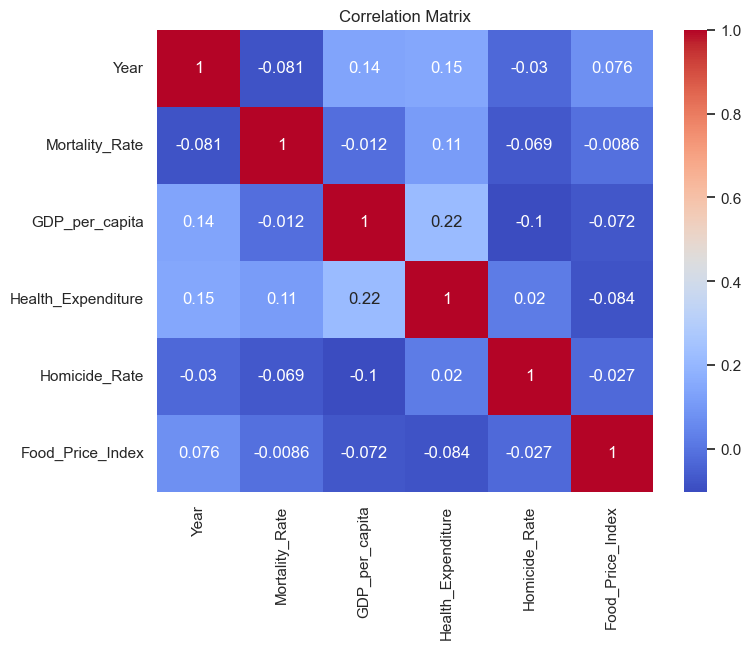

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Distribution Check

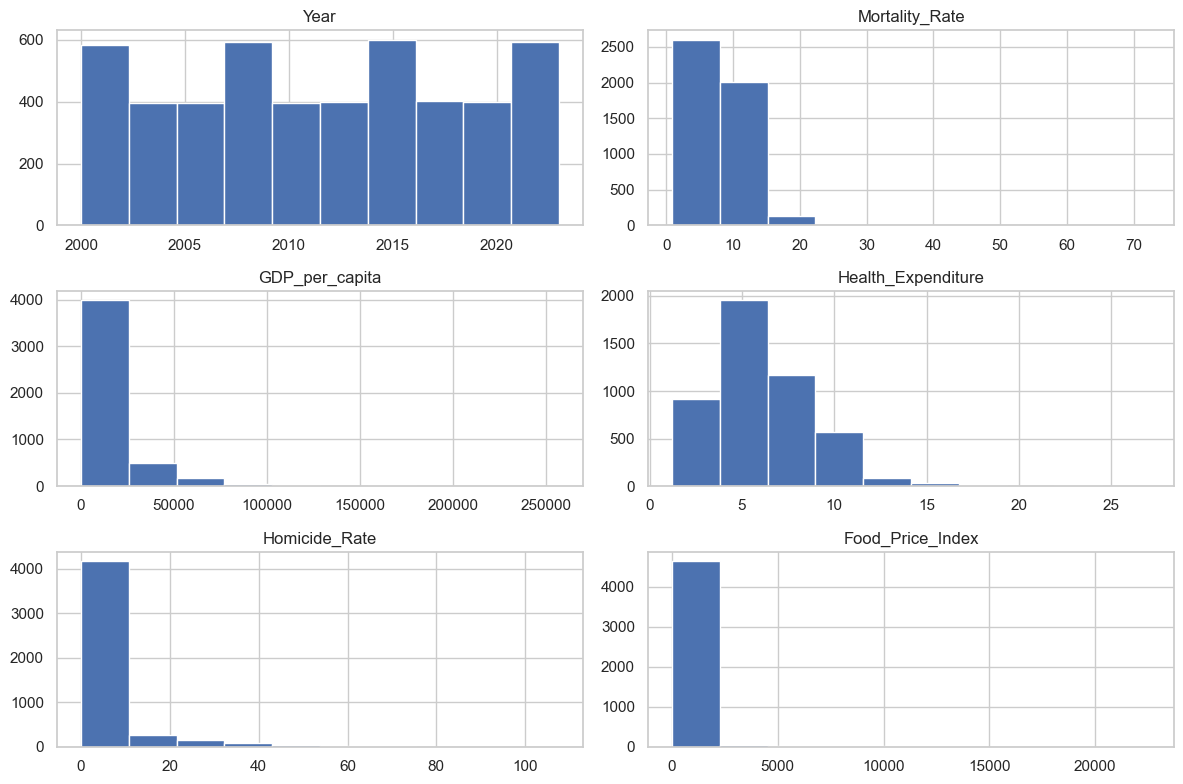

In [50]:
final_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

## Save Intermediate Processed Files
Store processed individual datasets for reproducibility.

In [56]:
PROCESSED_DATA_PATH = 'data/processed'
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

# save individual processed datasets
mortality_long.to_csv(os.path.join(PROCESSED_DATA_PATH, 'mortality_clean.csv'), index=False)
gdp_long.to_csv(os.path.join(PROCESSED_DATA_PATH, 'gdp_clean.csv'), index=False)
health_long.to_csv(os.path.join(PROCESSED_DATA_PATH, 'health_clean.csv'), index=False)
fao_agg.to_csv(os.path.join(PROCESSED_DATA_PATH, 'fao_clean.csv'), index=False)
crime_long.to_csv(os.path.join(PROCESSED_DATA_PATH, 'crime_clean.csv'), index=False)

# save final dataset
final_df.to_csv(os.path.join(PROCESSED_DATA_PATH, 'final_dataset.csv'), index=False)

print("✅ All processed datasets saved successfully!")

✅ All processed datasets saved successfully!
